## Combining metrics into one role score, without losing the raw numbers

Averaging raw per-90 values directly isn't an option: `totalOppositionHalfPasses_per90`
(roughly 30-40) would swamp `goals_per90` (roughly 0.1-0.6) purely on
scale, not because passing matters more than scoring. Each metric gets
converted to a percentile rank within the qualified population (0-100,
same scale regardless of the original unit) before combining, and each
role's score is the average of its metrics' percentiles.

This doesn't make the underlying numbers disappear. `role_metrics.csv`
still has every career total and per-90 rate for every individual metric,
the role score is an added column, not a replacement. Any table or chart
built from here on should show the composite score next to the raw stats
that produced it, not the score alone: "Messi: 91st percentile as a
chance creator (12 assists, 101 key passes, 24 big chances created)," not
just "91st percentile."

---

## Combinando métricas en un puntaje de rol, sin perder los números crudos

Promediar los valores per-90 crudos directamente no es una opción:
`totalOppositionHalfPasses_per90` (más o menos 30-40) le ganaría a
`goals_per90` (más o menos 0.1-0.6) puramente por escala, no porque pasar
importe más que convertir. Cada métrica se convierte a un percentil dentro
de la población calificada (0-100, misma escala sin importar la unidad
original) antes de combinar, y el puntaje de cada rol es el promedio de
los percentiles de sus métricas.

Esto no hace desaparecer los números de base. `role_metrics.csv` sigue
teniendo cada total de carrera y tasa per-90 de cada métrica individual,
el puntaje de rol es una columna agregada, no un reemplazo. Cualquier
tabla o gráfico que se arme de acá en adelante debería mostrar el puntaje
compuesto al lado de las estadísticas crudas que lo componen, no el
puntaje solo: "Messi: percentil 91 como creador de juego (12 asistencias,
101 pases clave, 24 grandes ocasiones creadas)", no solo "percentil 91".

In [3]:
import pandas as pd

role_metrics_df = pd.read_csv("../data/processed/role_metrics.csv")
print(role_metrics_df.shape)

role_metrics = {
    "finisher": ["goals", "totalShots", "onTargetScoringAttempt"],
    "dribbler": ["totalContest", "wonContest", "wasFouled"],
    "chance_creator": ["keyPass", "goalAssist", "bigChanceCreated", "totalCross", "accurateCross"],
    "play_organizer": ["totalPass", "accuratePass", "totalOppositionHalfPasses", "accurateOppositionHalfPasses", "touches"],
}

for role, cols in role_metrics.items():
    per90_cols = [f"{c}_per90" for c in cols]
    missing = [c for c in per90_cols if c not in role_metrics_df.columns]
    print(f"{role}: {len(per90_cols)} métricas, faltantes: {missing}")

(2488, 45)
finisher: 3 métricas, faltantes: []
dribbler: 3 métricas, faltantes: []
chance_creator: 5 métricas, faltantes: []
play_organizer: 5 métricas, faltantes: []


## Combining metrics into one role score, without losing the raw numbers

Averaging raw per-90 values directly isn't an option: `totalOppositionHalfPasses_per90`
(roughly 30-40) would swamp `goals_per90` (roughly 0.1-0.6) purely on
scale, not because passing matters more than scoring. Each metric gets
converted to a percentile rank within the qualified population (0-100,
same scale regardless of the original unit) before combining, and each
role's score is the average of its metrics' percentiles.

This doesn't make the underlying numbers disappear. `role_metrics.csv`
still has every career total and per-90 rate for every individual metric,
the role score is an added column, not a replacement. Any table or chart
built from here on should show the composite score next to the raw stats
that produced it, not the score alone: "Messi: 91st percentile as a
chance creator (12 assists, 101 key passes, 24 big chances created)," not
just "91st percentile."

---

## Combinando métricas en un puntaje de rol, sin perder los números crudos

Promediar los valores per-90 crudos directamente no es una opción:
`totalOppositionHalfPasses_per90` (más o menos 30-40) le ganaría a
`goals_per90` (más o menos 0.1-0.6) puramente por escala, no porque pasar
importe más que convertir. Cada métrica se convierte a un percentil dentro
de la población calificada (0-100, misma escala sin importar la unidad
original) antes de combinar, y el puntaje de cada rol es el promedio de
los percentiles de sus métricas.

Esto no hace desaparecer los números de base. `role_metrics.csv` sigue
teniendo cada total de carrera y tasa per-90 de cada métrica individual,
el puntaje de rol es una columna agregada, no un reemplazo. Cualquier
tabla o gráfico que se arme de acá en adelante debería mostrar el puntaje
compuesto al lado de las estadísticas crudas que lo componen, no el
puntaje solo: "Messi: percentil 91 como creador de juego (12 asistencias,
101 pases clave, 24 grandes ocasiones creadas)", no solo "percentil 91".

In [5]:
role_scores = role_metrics_df[["id", "name"]].copy()

for role, cols in role_metrics.items():
    per90_cols = [f"{c}_per90" for c in cols]
    percentile_cols = []
    for col in per90_cols:
        pct_col = f"{col}_pct"
        role_metrics_df[pct_col] = role_metrics_df[col].rank(pct=True) * 100
        percentile_cols.append(pct_col)
    role_scores[f"{role}_score"] = role_metrics_df[percentile_cols].mean(axis=1)

messi_id = role_metrics_df[role_metrics_df["name"].str.contains("Messi", case=False, na=False)]["id"].values[0]

print("Puntaje compuesto de creador de juego:")
print(role_scores[role_scores["id"] == messi_id][["name", "chance_creator_score"]])

print("\nMétricas crudas detrás de ese puntaje:")
raw_cols = ["keyPass", "keyPass_per90", "goalAssist", "goalAssist_per90",
            "bigChanceCreated", "bigChanceCreated_per90"]
print(role_metrics_df[role_metrics_df["id"] == messi_id][["name"] + raw_cols])

Puntaje compuesto de creador de juego:
             name  chance_creator_score
367  Lionel Messi             92.130225

Métricas crudas detrás de ese puntaje:
             name  keyPass  keyPass_per90  goalAssist  goalAssist_per90  \
367  Lionel Messi    101.0       2.976424        12.0          0.353635   

     bigChanceCreated  bigChanceCreated_per90  
367              24.0                0.707269  


In [6]:
for role, cols in role_metrics.items():
    per90_cols = [f"{c}_per90" for c in cols]
    percentile_cols = [f"{c}_pct" for c in per90_cols]
    role_scores[f"{role}_score"] = role_metrics_df[percentile_cols].mean(axis=1)

print(role_scores.describe())
print()

messi_scores = role_scores[role_scores["id"] == messi_id]
print("Los 4 puntajes de Messi:")
print(messi_scores)

                 id  finisher_score  dribbler_score  chance_creator_score  \
count  2.488000e+03     2488.000000     2488.000000           2488.000000   
mean   8.867643e+05       50.020096       50.020096             50.020096   
std    6.390709e+05       24.444119       25.155280             21.563557   
min    1.000000e+00       17.852358        4.642283             18.938907   
25%    5.153625e+04       28.339362       29.513331             31.109325   
50%    1.418866e+06       46.359191       49.450697             49.093650   
75%    1.420566e+06       70.838357       70.600549             66.024920   
max    2.520524e+06      100.000000       99.531083             99.746785   

       play_organizer_score  
count           2488.000000  
mean              50.020096  
std               26.572354  
min                0.281350  
25%               28.136053  
50%               49.511656  
75%               72.458802  
max               99.967846  

Los 4 puntajes de Messi:
        id

In [7]:
role_cols = ["finisher_score", "dribbler_score", "chance_creator_score", "play_organizer_score"]
correlation_matrix = role_scores[role_cols].corr()
print(correlation_matrix.round(3))

                      finisher_score  dribbler_score  chance_creator_score  \
finisher_score                 1.000           0.548                 0.485   
dribbler_score                 0.548           1.000                 0.583   
chance_creator_score           0.485           0.583                 1.000   
play_organizer_score           0.024           0.131                 0.297   

                      play_organizer_score  
finisher_score                       0.024  
dribbler_score                       0.131  
chance_creator_score                 0.297  
play_organizer_score                 1.000  


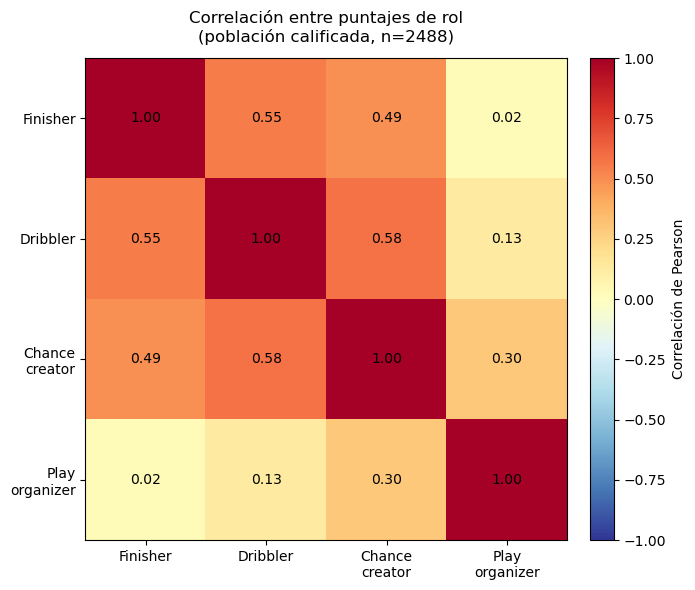

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation_matrix, cmap="RdYlBu_r", vmin=-1, vmax=1)

labels = ["Finisher", "Dribbler", "Chance\ncreator", "Play\norganizer"]
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Correlación de Pearson", fraction=0.046, pad=0.04)
ax.set_title("Correlación entre puntajes de rol\n(población calificada, n=2488)", pad=12)

plt.tight_layout()
plt.savefig("../reports/figures/role_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## What this correlation pattern actually shows

Two different stories, not one. Play organizer correlates weakly with all
three other roles (0.02 with finisher, 0.13 with dribbler, 0.30 with
chance creator): organizing play from a deeper position behaves as a
genuinely distinct skill dimension from attacking output, largely
independent of it. The other three roles correlate moderately with each
other (0.49-0.58): finishing, dribbling, and chance creation share some
common variance, plausibly something like "attacking quality," exercised
in overlapping match situations.

This matters for how Phase 5's multi-role elite count should be read, not
just computed. Because the three attacking roles aren't independent of
each other, being elite in two or three of them simultaneously is
partially explained by that shared correlation, it's not automatically as
rare as combining four fully independent dimensions would be. Being elite
in an attacking role *and* play organizer is a different kind of claim,
those two are close to statistically independent, so an elite score in
both isn't something the correlation structure would predict on its own.
Phase 5 should distinguish between these two cases rather than treating
"elite in N of 4 roles" as equally surprising regardless of which N roles
those are.

This is a finding about the population's correlation structure, not yet
about Messi specifically. Where his four scores fall relative to this
structure is Phase 5's question.

---

## Qué muestra realmente este patrón de correlación

Dos historias distintas, no una sola. Organizador de juego correlaciona
débilmente con los otros tres roles (0.02 con finalizador, 0.13 con
desequilibrante, 0.30 con creador de juego): organizar el juego desde una
posición más retrasada se comporta como una dimensión de habilidad
genuinamente distinta al rendimiento ofensivo, en gran medida
independiente de él. Los otros tres roles correlacionan de forma moderada
entre sí (0.49-0.58): finalización, desequilibrio y creación de juego
comparten algo de varianza común, plausiblemente algo así como "calidad
ofensiva", ejercida en situaciones de partido que se superponen.

Esto importa para cómo hay que leer el conteo de élite multi-rol de la
Fase 5, no solo para cómo se calcula. Como los tres roles ofensivos no son
independientes entre sí, ser élite en dos o tres de ellos simultáneamente
se explica en parte por esa correlación compartida, no es automáticamente
tan raro como combinar cuatro dimensiones completamente independientes.
Ser élite en un rol ofensivo *y* en organizador de juego es un tipo de
afirmación distinto, esos dos están cerca de ser estadísticamente
independientes, así que un puntaje de élite en ambos no es algo que la
estructura de correlación predeciría por sí sola. La Fase 5 debería
distinguir entre estos dos casos en vez de tratar "élite en N de 4 roles"
como igual de sorprendente sin importar cuáles N roles sean.

Este es un hallazgo sobre la estructura de correlación de la población,
todavía no sobre Messi específicamente. Dónde caen sus cuatro puntajes
respecto a esta estructura es la pregunta de la Fase 5.

In [10]:
role_scores.to_csv("../data/processed/role_scores.csv", index=False)
print(f"Guardado: {role_scores.shape[0]} jugadores, {role_scores.shape[1]} columnas")

Guardado: 2488 jugadores, 6 columnas


## Why play organizer was chosen as the distant role, and what that predicts for Phase 5

Finisher, dribbler, and chance creator describe variants of the same
general attacking profile. Players routinely move between these labels
over a career (a winger becoming a striker, a striker dropping into a
playmaker role, a playmaker shifting wide) without changing what kind of
player they fundamentally are. Play organizer describes a materially
different function, a deeper build-up role, a bigger positional and
functional jump than the distance between the other three. That reasoning
predates this notebook, it's implicit in how the four archetypes were
defined from the start of the project. Now that the correlation numbers
confirm it (0.02-0.30 vs. 0.49-0.58), it's worth stating explicitly, and
being clear that the logic came first, not invented afterward to explain
the number.

That sets up a concrete, pre-registered prediction for Phase 5, written
down before the elite cutoff exists or the multi-role count runs:
Messi's 84th-percentile play_organizer_score is notable on its own terms,
given how distant that role is from his dominant skillset (97.19 / 95.73
/ 92.13 in the other three), regardless of whether it clears whatever
"elite" threshold Phase 5 defines. He is explicitly *not* predicted to
rank top-5, top-10, or even top-20/30 specifically in play organizer.
Separately: the moderate correlation among the three attacking roles at
the population level does not guarantee that any individual elite
finisher, dribbler, or creator will also be elite in the other correlated
roles, that's an aggregate pattern, not a per-player guarantee, and Phase
5 should check it directly rather than assume it.

---

## Por qué se eligió organizador como el rol lejano, y qué predice eso para la Fase 5

Finalizador, desequilibrante y creador de juego describen variantes de un
mismo perfil general ofensivo. Los jugadores se mueven habitualmente entre
estas etiquetas a lo largo de una carrera (un extremo que se convierte en
delantero, un delantero que retrocede a mediapunta, un mediapunta que se
abre a la banda) sin cambiar fundamentalmente qué tipo de jugador son.
Organizador de juego describe una función sustancialmente distinta, un
rol de construcción más retrasado, un salto posicional y funcional más
grande que la distancia entre los otros tres. Ese razonamiento es
anterior a este notebook, está implícito en cómo se definieron los cuatro
arquetipos desde el inicio del proyecto. Ahora que los números de
correlación lo confirman (0.02-0.30 contra 0.49-0.58), vale la pena
dejarlo explícito, y dejar claro que la lógica vino primero, no se
inventó después para explicar el número.

Eso arma una predicción concreta y pre-registrada para la Fase 5, escrita
antes de que exista el corte de élite o corra el conteo multi-rol: el
percentil 84 de Messi en `play_organizer_score` es notable en sí mismo,
dado lo lejano que es ese rol de su perfil dominante (97.19 / 95.73 /
92.13 en los otros tres), sin importar si termina superando el umbral de
"élite" que defina la Fase 5. Explícitamente *no* se predice que quede
top-5, top-10, ni siquiera top-20/30 específicamente en organizador. Por
separado: la correlación moderada entre los tres roles ofensivos a nivel
poblacional no garantiza que un finalizador, desequilibrante o creador
élite puntual también vaya a ser élite en los otros roles correlacionados,
eso es un patrón agregado, no una garantía por jugador, y la Fase 5
debería revisarlo directamente en vez de asumirlo.

## Phase 4 conclusion

Combined the 16 role-assigned metrics into four composite percentile
scores per player, keeping the raw stats visible alongside every score
rather than replacing them. The four roles don't behave as one
undifferentiated "good player" axis: the three attacking roles share
moderate correlation with each other (0.49-0.58), while play organizer is
close to independent of all three (0.02-0.30), confirming the reasoning
behind treating it as a functionally distant role from the start.

This structure matters for how Phase 5 reads its results, not just how it
computes them. Being elite in multiple attacking roles at once is
partially explained by their shared correlation; being elite in an
attacking role and play organizer simultaneously isn't, since those are
close to statistically independent. A pre-registered prediction is on the
record for Phase 5 to test: Messi's 84th percentile in play organizer is
notable given that independence, regardless of whether it clears
whatever elite threshold gets defined there.

**Result:** `data/processed/role_scores.csv`, one row per qualified
player (n=2488) with four percentile-based role scores. This, together
with `role_metrics.csv` for the underlying raw numbers, is what Phase 5
(multi-role elite count) will work from.

---

## Conclusión de la Fase 4

Se combinaron las 16 métricas asignadas a rol en cuatro puntajes
compuestos de percentil por jugador, manteniendo las estadísticas crudas
visibles junto a cada puntaje en vez de reemplazarlas. Los cuatro roles
no se comportan como un solo eje indiferenciado de "buen jugador": los
tres roles ofensivos comparten correlación moderada entre sí (0.49-0.58),
mientras que organizador de juego está cerca de ser independiente de los
tres (0.02-0.30), confirmando el razonamiento detrás de tratarlo como un
rol funcionalmente lejano desde el principio.

Esta estructura importa para cómo la Fase 5 lee sus resultados, no solo
para cómo los calcula. Ser élite en varios roles ofensivos a la vez se
explica en parte por su correlación compartida; ser élite en un rol
ofensivo y en organizador de juego simultáneamente no, porque esos dos
están cerca de ser estadísticamente independientes. Queda registrada una
predicción pre-registrada para que la Fase 5 la ponga a prueba: el
percentil 84 de Messi en organizador es notable dada esa independencia,
sin importar si termina superando el umbral de élite que se defina ahí.

**Resultado:** `data/processed/role_scores.csv`, una fila por jugador
calificado (n=2488) con los cuatro puntajes de rol basados en percentil.
Esto, junto con `role_metrics.csv` para los números crudos de base, es
desde donde va a trabajar la Fase 5 (conteo de élite multi-rol).